---

# Part 1: Dataset Analysis
## The Real-World Tropical Forest Camera-Trap Biodiversity Analysis

Analysing and working with a real subset of a tropical forest camera‑trap biodiversity dataset.  
The dataset has the following columns in this same order shown here:

| Field Name | Description | Type | Example Value |
| :--- | :--- | :--- | :--- |
| **`survey_id`** | Unique ID of survey the record comes from. | `string` | `Lambir2017.ECL` |
| **`records`** | Number of independent records (detections). | `int` | `9` |
| **`dataset`** | Subset identifier. | `string` | `ECL` |
| **`Y_lat`** | Latitude of the survey in decimal degrees (WGS84). | `float` | `4.199` |
| **`X_long`** | Longitude of the survey in decimal degrees (WGS84). | `float` | `114.021` |
| **`year_start`** | Year the trapping survey started. | `int` | `2017` |
| **`country`** | Country where the sampling was performed. | `string` | `Malaysia` |
| **`domestic`** | Indicates if the species is domestic or wild. | `string` | `wild` |
| **`uri`** | Link to the species webpage (NCBI or GBIF). | `string` | `https://www.ncbi...` |
| **`class`** | Class name | `string` | `Mammalia` |
| **`order`** | Order name | `string` | `Primates` |
| **`family`** | Family name | `string` | `Cercopithecidae` |
| **`genus`** | Genus name | `string` | `Macaca` |
| **`species`** | Species name | `string` | `fascicularis` |
| **`binomial_verified`** | Validated binomial name (via NCBI/GBIF). | `string` | `Macaca fascicularis` |
| **`taxonomic_level`** | The most specific taxonomic level identified. | `string` | `species` |


## Task 1 — Load the dataset

Load `dataset.csv` into a pandas DataFrame called `data` and insert the correct column names from the table above as they are currently missing in the csv.
Display the first 5 rows and the general information about the dataset.


**🧑‍💻 SOLUTION CELL**

In [1]:


import pandas as pd

#giving the columns names as specified above in the table as they are not there in the dataset.
columns=["survey_id","records","dataset","Y_lat","X_long","year_start","country", "domestic", "uri", "class", "order", "family",
    "genus", "species", "binomial_verified", "taxonomic_level"]                 

#setting the header as None because initially the csv file does not have header row its more like telling the pandas that there is no header row.
data = pd.read_csv('dataset.csv',header=None,names=columns)

""" using data.head() will give us the first 5 rows automatically without intially specifing the no of rows needed,
when we need more rows specify the no of rows needed like data.head(20), 
and also data.tail() will give the output as the last 5 rows """

print("The fisrt 5 rows of this dataset are:")     
print(data.head())
#print(data.tail())

#gives the dataset overview like row count, column name, datatypes, non null count
print("General information about this dataset are:")
print(data.info())



FileNotFoundError: [Errno 2] No such file or directory: 'dataset.csv'


## Task 2 — Ecological Exploratory Data Analysis 

**Goal:** Understand biodiversity distribution across the region using `pandas`, `scipy` and `matplotlib`.

**Task:**
1. Load the dataset and filter for `"wild"` animals only.
1. **Contingency Table:** Create a contingency table (crosstab) between `country` and `order` (e.g., Primates, Carnivora, Artiodactyla).
1. **Statistical Test:** Use the appropriate statistical test to analyze independence in this table.
1. **Visualization:** Plot with bar charts the top 5 `orders` per `country` to visualize the relationship.

**🧑‍💻 SOLUTION CELL**

              survey_id  records            dataset     Y_lat      X_long  \
0               137.SEA       30                SEA -2.264451  101.794251   
1               138.SEA       21                SEA -2.031408  101.126884   
2               139.SEA       10                SEA -3.024615  101.950937   
3               135.SEA        5                SEA  3.717770  102.128800   
4               120.SEA        6                SEA -0.921494  102.385766   
...                 ...      ...                ...       ...         ...   
4549  Danum_Valley_2022        4  Danum_Valley_2022  4.955966  117.788104   
4550  Danum_Valley_2022        4  Danum_Valley_2022  4.955966  117.788104   
4551  Danum_Valley_2022        1  Danum_Valley_2022  4.955966  117.788104   
4552  Danum_Valley_2022        1  Danum_Valley_2022  4.955966  117.788104   
4553  Danum_Valley_2022        1  Danum_Valley_2022  4.955966  117.788104   

      year_start    country domestic  \
0           2014  Indonesia     wil

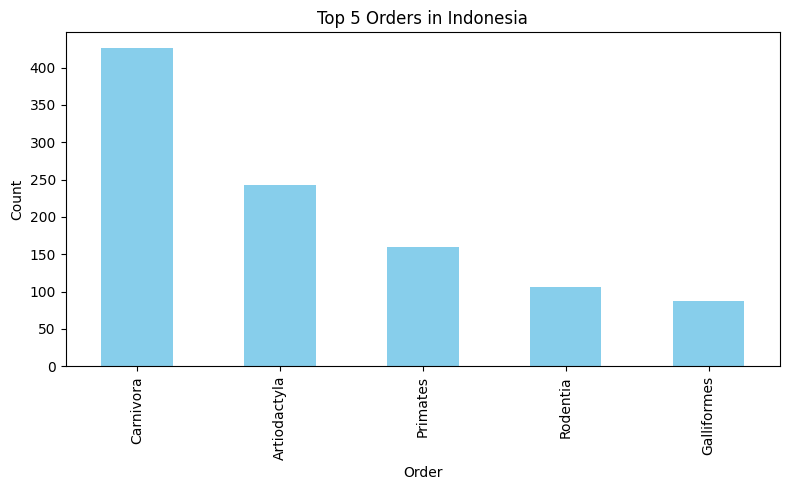

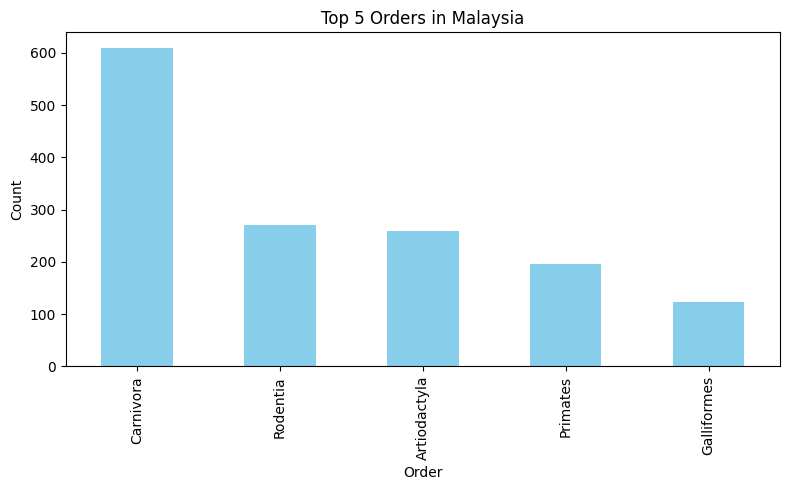

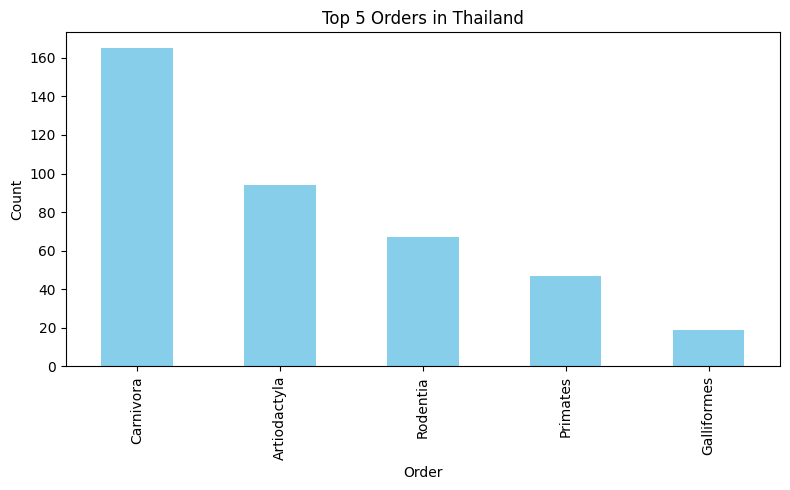

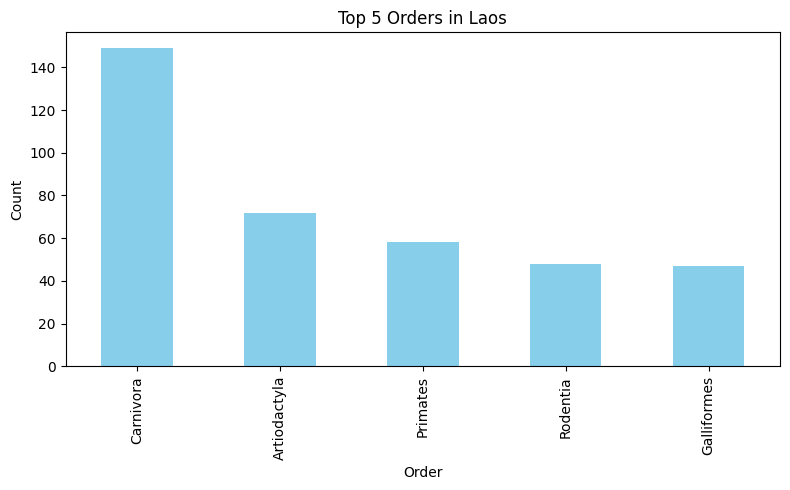

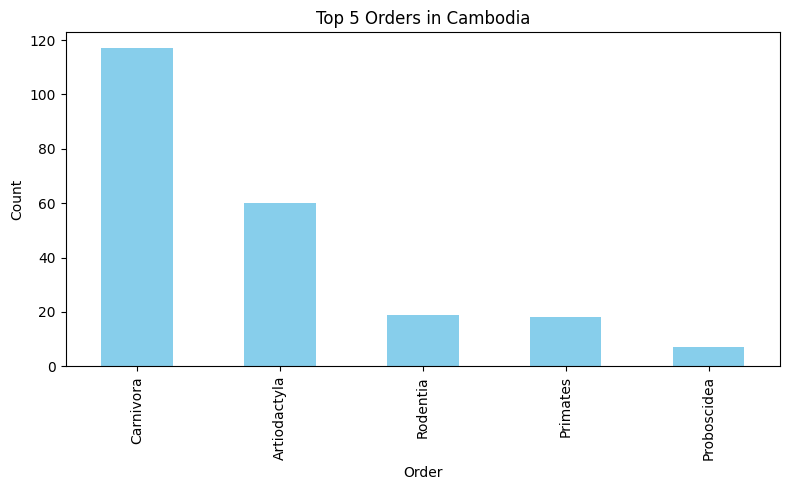

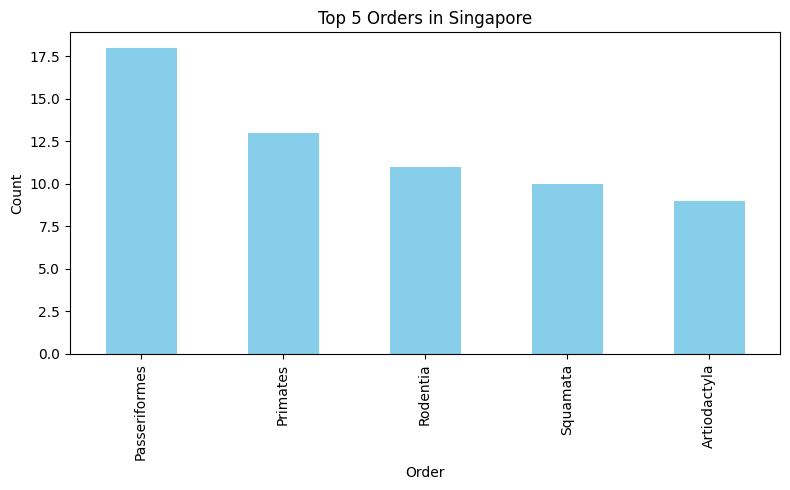

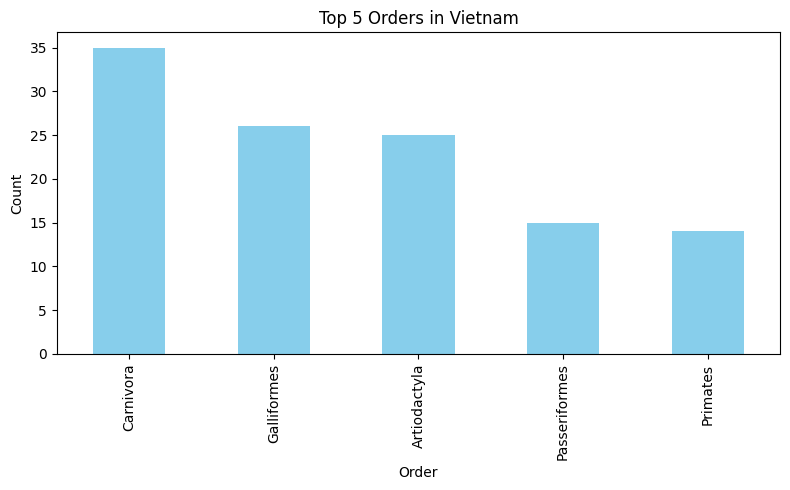

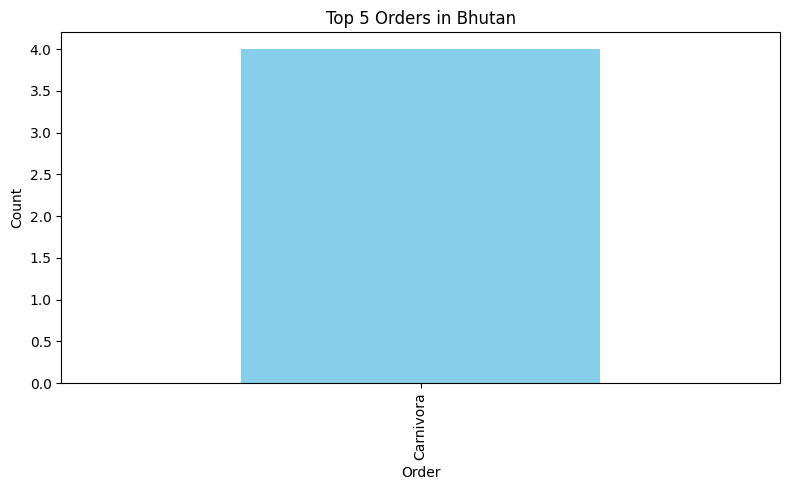

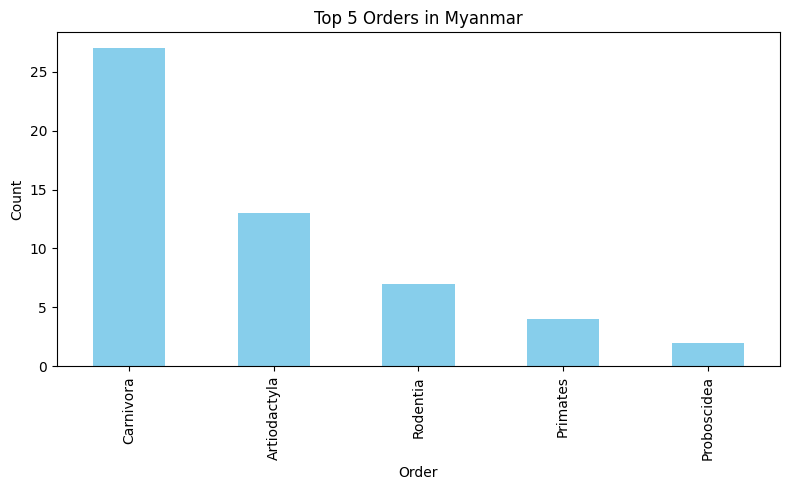

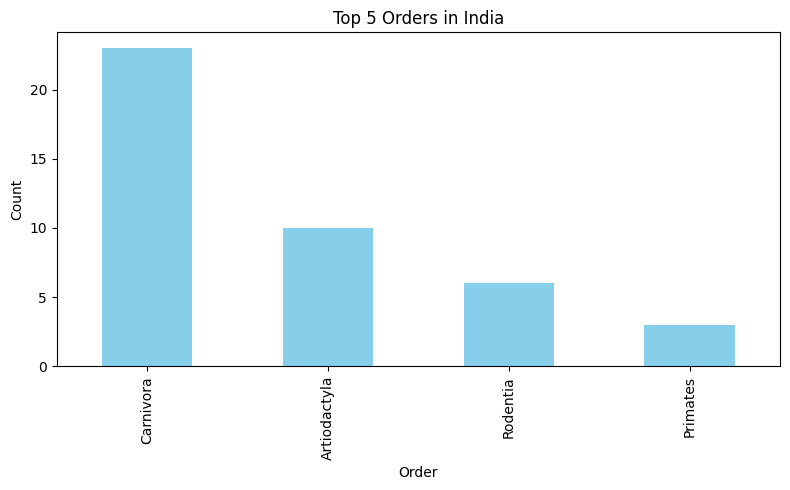

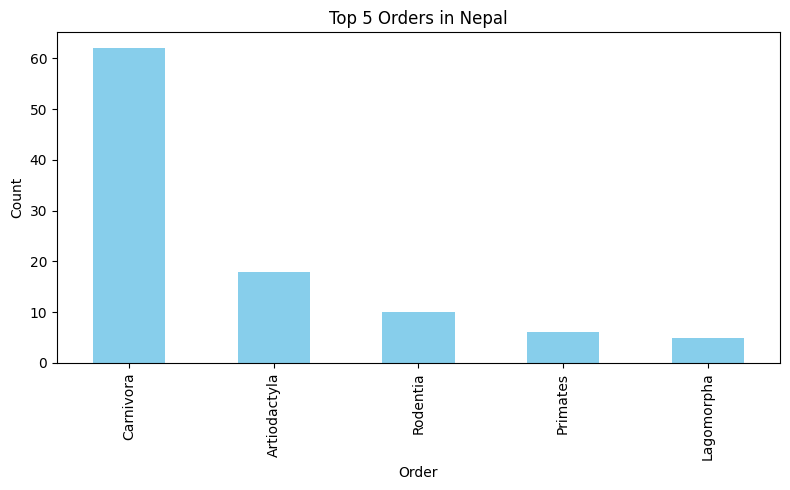

In [ ]:


import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

#filtering done for getting only the wild animals from the domestic column.
wild_data= data.loc[data["domestic"]=="wild"]
print(wild_data)

#crosstab is implememnted between country and order in the wild category inorder to understand the distribution of wild animlas order in different countries
contingency_table=pd.crosstab(wild_data["country"], wild_data["order"])
print("contingency_table:\n",contingency_table)

#Performing the Chi-square Test of Independence, this helps as understand the correlation between animal order and country
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)                                   #crosstab and Chi-square Test referenced from Lecture works[9].
print("Expected frequencies:\n", expected)

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print("P-vaue:",p)

if p < 0.05:
    print("Orders depend on country which means dependent")
else:            #if p >= 0.05
    print("orders are independent of country")


#Ploting the bar charts with the top 5 `orders` per `country` to visualize the relationship. 
for country in wild_data["country"].unique():                                                   #This particular method referenced from Data mining Lecture notes.
    top_orders=wild_data[wild_data["country"]== country]["order"].value_counts().head(5)
    top_orders.plot(kind="bar", figsize=(8,5), color="skyblue")
    plt.title(f"Top 5 Orders in {country}")
    plt.xlabel("Order")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



## Q.
*Is the distribution of animal Orders independent of the Country? In other words, do different countries tend to have significantly different compositions of animal types? Explain how did you arrive at your conclusions.*



Here from the statistics it is understandable that animal order is not independent of the country, which means animal order is dependent on country.

This interpretation is done by observing the p-value, The chi-square statistics and degree of freedom, out of these values, p-value is the most important one. 

If p < 0.05, we will reject the null hypothesis and assumes that there is a significant relationship and if p > 0.05 - fails to reject the null hypothesis and assumes as independent (No significant relationship).

Here the p-value is 2.4066972466764778e-74 which is less than 0.05, which implies significant relationship between orders and country.

Different countries have different composition of animal types, this is also visible from the bar charts of diffrent countires.

In conclusion, from this statistics it clear that animal order depends on each country and it varies differently in each country which is visible from the bar chart created. 




## Task 3 — Spatiotemporal Scatter Plots

**Goal:** Visualize sampling effort over space and time using standard scatter plots. Use `pandas` and `matplotlib`.

**Tasks:**
1. Create a figure using `matplotlib.pyplot.subplots` to contain two subplots horizontally stacked.
1. Use `ax.scatter()` to plot `X_long` on the x-axis and `Y_lat` on the y-axis.
1. Pass the `year_start` column to the `c` (color) argument of the scatter function to create a time-gradient map. Add a colorbar (`plt.colorbar`) to show the year range.
1. Create a second scatter plot filtering for only *Panthera tigris* (Tiger). Use the `s` (size) argument to scale the points based on the number of `records`.


**🧑‍💻 SOLUTION CELL**

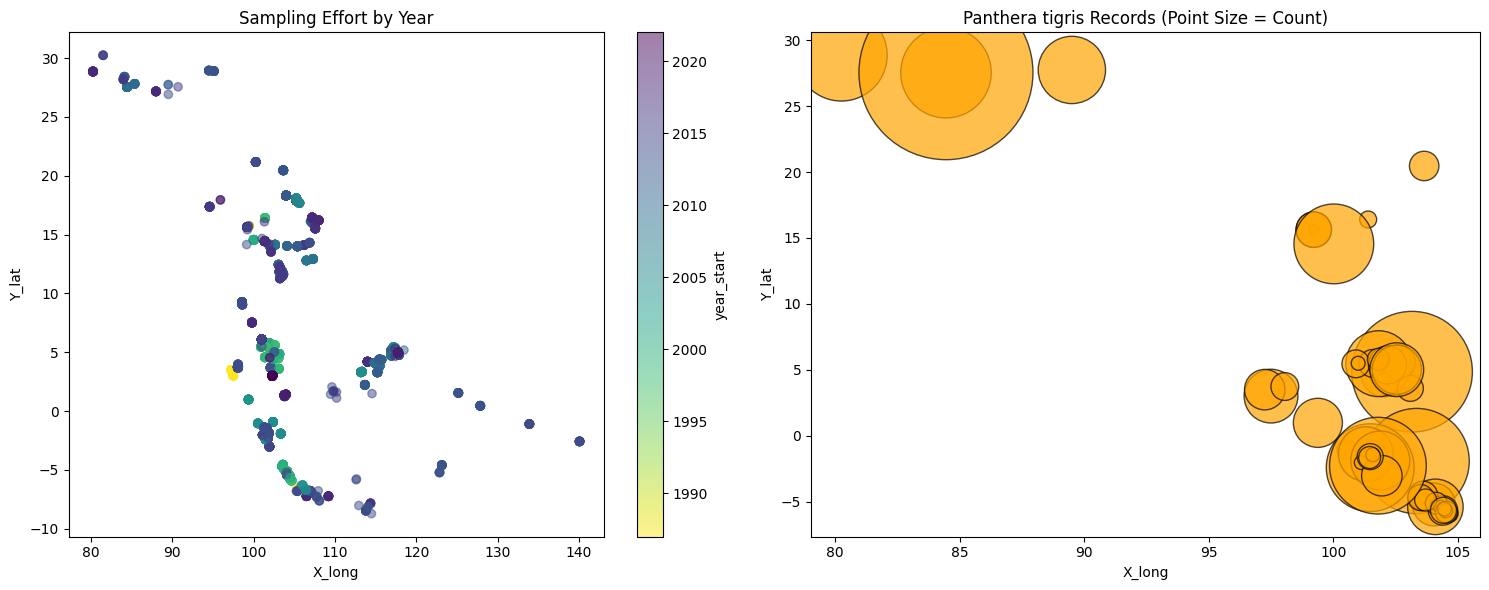

In [ ]:


#Creating a figure with two subplots horizontally stacked (1 row, 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

#Subplot 1: Using X_long for x-axis and Y_lat for y-axis as mentioned
#passing the 'year_start' to the Color (c) column for creating time-gradient map [2]
sc1 = axs[0].scatter(data['X_long'], data['Y_lat'], 
                     c=data['year_start'], cmap='viridis_r', alpha=0.5)

axs[0].set_xlabel("X_long")
axs[0].set_ylabel("Y_lat")
axs[0].set_title("Sampling Effort by Year")

# Adding the colorbar to the first subplot
cbar = plt.colorbar(sc1, ax=axs[0])
cbar.set_label('year_start')


#Subplot 2: Used for filtering Panthera tigris only
tiger_df = data[data['binomial_verified'] == 'Panthera tigris']

#Using the `s` (size) argument to scale the points based on the number of `records`.
# We multiply by a factor (like 10 or 20) to make the size differences easy to see referenced from [3]
axs[1].scatter(tiger_df['X_long'], tiger_df['Y_lat'], 
               s=tiger_df['records'] * 50, color='orange', alpha=0.7, edgecolor='k')

axs[1].set_xlabel("X_long")
axs[1].set_ylabel("Y_lat")
axs[1].set_title("Panthera tigris Records (Point Size = Count)")

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()

### **Question:** 
*Do older studies (lighter colors) tend to be clustered in specific countries compared to newer studies (darker colors)?*

📝 **ANSWER CELL**



Yes, Older studies(lighter colours) do appear more clustered in particular regions, but newer studies(darker colours) are spreaded across the latitude and longitude.

Also the older studies distribution is less in overall, but newer studies are wide spread.

## Task 4 — Predator vs. Primate Clustering 
* **Goal:** Group survey sites based on the abundance of two distinct animal groups: **Carnivores** and **Primates**. Use `pandas`, `sklearn`, `matplotlib`.

In the lecture, we used **DBSCAN** to find density-based clusters. Here, we will use **[K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**, a very common algorithm that partitions data into $k$ specific groups based on distance to a center point. It uses the same `.fit()` and `.predict()` syntax you learned for Regression and Classification.

**Tasks:**
* **Data Prep:**
    1.  Create a variable `carnivores` (a `Series`) which contains the number of records found for all carnivores by `survey_id` (note, there are multiple entries for each `survey_id`). You can do this by filtering the data for `order == 'Carnivora'`, grouping by `survey_id`, and summing `records`.
    2.  Do the same for primates, creating a `primates` variable containig a `Series` generated by filtering for `order == 'Primates'`, grouping by `survey_id`, and summing `records`.
    3.  Combine these into a new DataFrame: `df_cluster = pd.DataFrame({'Carnivora': carnivores, 'Primates': primates})`.
    4.  Fill any missing values (`NaN`) with 0.
* **Modeling (K-Means):**
    1.  Import `KMeans` from `sklearn.cluster`.
    2.  Initialize the model with 4 clusters; refer to the documentation: [https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).
    3.  Fit and predict clusters on your `df_cluster` data. Store the results in a variable `labels`.
* **Visualization:**
    1.  Create a scatter plot with 'Carnivora' on the X-axis and 'Primates' on the Y-axis.
    2.  Color the points using the `labels` you generated.

**🧑‍💻 SOLUTION CELL**

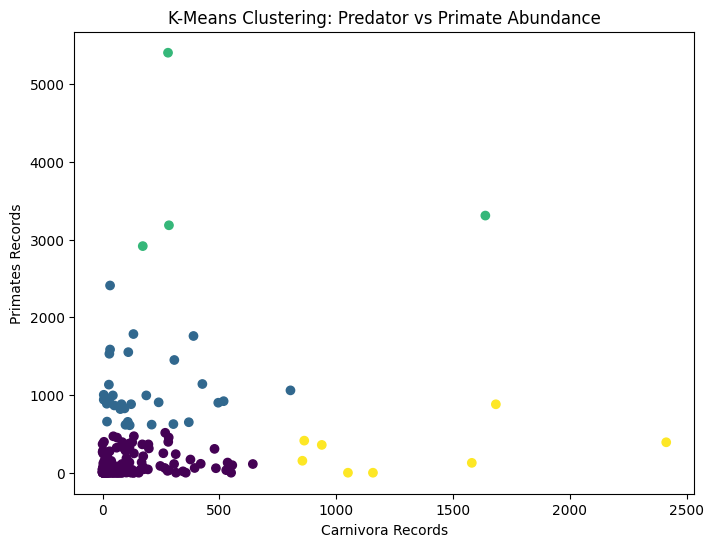

In [ ]:


#Filtering the dataset for Carnivora, grouping by survey_id, and summing records.
carnivores = (data[data['order'] == 'Carnivora'].groupby('survey_id')['records'].sum())   

#Filtering the dataset for Primates, grouping by survey_id, and summing records.
primates = (data[data['order'] == 'Primates'].groupby('survey_id')['records'].sum())        

#combing both Carnivores and Primates into one Dataframe
df_cluster = pd.DataFrame({'Carnivora': carnivores,'Primates': primates})                   

#filling the missing values with 0
df_cluster = df_cluster.fillna(0)                                                           

#importing Kmeans for clustering [4]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42)   #n_cluster=4 means 4 clusters
labels = kmeans.fit_predict(df_cluster)          #fitting the model with data and predicting the cluster label(fit_predict)
df_cluster['Cluster'] = labels                   #storing the result in the variable 'label'

#Creating a scatter plot with 'Carnivora' on the X-axis and 'Primates' on the Y-axis.
plt.figure(figsize=(8, 6))
plt.scatter(
    df_cluster['Carnivora'],    #X-axis
    df_cluster['Primates'],     #Y-axis
    c=labels,                   # color by cluster
    cmap=None        
)
plt.xlabel("Carnivora Records")
plt.ylabel("Primates Records")
plt.title("K-Means Clustering: Predator vs Primate Abundance")
plt.show()


### **Question:** 
*Look at the plot. Do the three clusters represent sites that are "High Primate/Low Carnivore", "High Carnivore/Low Primate", and "Low Activity"?*

📝 **ANSWER CELL**



The violet cluster at the bottom-left corner which represents the low carnivore and low primate level, which is the low activity because it is neither HighPrimate/Lowcarnivore nor Highcarnivore/Lowprimate.

The blue cluster in the mid-left which represents moderate primate and low carnivore level.

The green cluster in the upper-left which represents high primate and low to modearte carnivore records, here there is strong primate activity.

The yellow cluster in the right side, which represents high carnivore and low to moderate primate level, here there is high carnivore activity.

From the image there is no cluster with proper "High Primate/Low Carnivore", "High Carnivore/Low Primate" but it represents different levels.



## Task 5 — Biodiversity Index Calculation & Statistical Testing

**Goal:** Quantify diversity and test for statistical differences using `pandas`, `numpy`, `scipy`.

You are already provided with a Python function that accepts a list of counts and returns the **Shannon Diversity Index ($H'$)**:
       $$H' = -\sum (p_i \cdot \ln(p_i))$$

**Task:**
1. Apply this function to each `survey_id` providing the list of counts for each species in that survey to get a single diversity score for every survey.
1. Separate the diversity scores into three lists: one for surveys in "Malaysia", one for surveys in "Indonesia" and one in "Thailand".
1. Use the *appropriate* statistical test using `scipy` to compare the three groups and check if there are statistical differences.


**🧑‍💻 SOLUTION CELL**

In [ ]:
def calculate_shannon_index(counts):
    """
    Calculates the Shannon Diversity Index (H') for a single site.
    
    Args:
        counts (array-like): A list or Pandas Series containing the counts 
                             of individuals for each species found at the site.
                             Example: [10, 5, 3] (10 of sp A, 5 of sp B, 3 of sp C)
    
    Returns:
        float: The Shannon Diversity Index value.
    """
    # 1. Convert to numpy array to handle math easily
    counts = np.array(counts)
    
    # 2. Calculate Total Abundance (N)
    total = np.sum(counts)
    
    # 3. Handle empty sites (avoid division by zero)
    if total == 0:
        return 0.0
    
    # 4. Calculate Proportions (pi)
    proportions = counts / total
    
    # 5. Filter out 0 counts (because log(0) is undefined)
    proportions = proportions[proportions > 0]
    
    # 6. Formula: -Sum(pi * ln(pi))
    return -np.sum(proportions * np.log(proportions))



#1.
#Applying the Shannon function to each survey_id using the list of species counts[9]
diversity_scores = (
    data.groupby('survey_id')['records']
            .apply(calculate_shannon_index)
)
print("Shannon Diversity per Survey")
print(diversity_scores.head(), "\n")


#converting the diversity scores series into a dataframe 
df_div = diversity_scores.reset_index()
df_div.columns = ['survey_id', 'diversity']

#adding the country information for each survey_id
df_div = df_div.merge(
    data[['survey_id', 'country']].drop_duplicates(),
    on='survey_id'
)

print("Diversity with Country Info")
print(df_div.head(), "\n")

#2.
#Separting the diversity scores into three list - 1.Malaysia, 2.Indonesia, 3.Thailand
malaysia = df_div[df_div['country'] == 'Malaysia']['diversity']
indonesia = df_div[df_div['country'] == 'Indonesia']['diversity']
thailand = df_div[df_div['country'] == 'Thailand']['diversity']

print("Malaysia Diversity Scores")
print(malaysia.values, "\n")

print("Indonesia Diversity Scores")
print(indonesia.values, "\n")

print("Thailand Diversity Scores")
print(thailand.values, "\n")


#3.
#Using Statistical test (Kruskal–Wallis) for comparing the three groups and checking its ststistical differences.[5][9]
from scipy.stats import kruskal

stat, p = kruskal(malaysia, indonesia, thailand)

print("Kruskal Wallis Test")
print("Statistic:", stat)
print("p-value:", p)


Shannon Diversity per Survey
survey_id
1.SEA      2.035035
109.SEA    2.353006
110.SEA    2.178657
111.SEA    1.660520
112.SEA    1.397650
Name: records, dtype: float64 

Diversity with Country Info
  survey_id  diversity   country
0     1.SEA   2.035035  Cambodia
1   109.SEA   2.353006  Malaysia
2   110.SEA   2.178657  Malaysia
3   111.SEA   1.660520  Malaysia
4   112.SEA   1.397650  Malaysia 

Malaysia Diversity Scores
[ 2.35300636  2.17865741  1.66052039  1.39765001  2.23315615  1.89295614
  2.28115211  2.43371263  1.67381856  2.2412552   2.41773166  2.1281781
  1.98601679  2.50670373  2.12891987  2.34239055  2.24880526  2.21752473
  2.39201087  1.61898859  1.61254242  1.91042246  2.26618089  1.68220097
  1.99381156  2.34072415  2.64099841  2.6476631   2.52444828  2.45446551
  2.24710784 -0.          2.81274089  2.69956262  2.633456    2.35439613
  0.62248692  2.25943685  0.75724593  2.03180142 -0.          2.18910189
 -0.         -0.         -0.          1.5150902  -0.         -0.


### **Question:** 
*Is the difference in mean biodiversity between Malaysia, Indonesia and Thailand statistically significant?*

📝 **ANSWER CELL**

Your answer here:

In the Kruskal wallis Test we mainly focus on the p-value for understanding its statistical importance.

Here the p-value from the Kruskal–Wallis is 0.12149709664858149, 
which is greater than 0.05, which means it fails to reject the null hypothesis and it indicates that the difference in median between malaysia, Indonesia and Thailand is due to random variation, which impiles - no significant difference in biodiversity was found between countries.

## Task 6 — Smooth Population Trends 
* **Goal:** Visualize biological trends more naturally by estimating missing data with smooth curves using `pandas`, `scipy`, `numpy`, `matplotlib`.

**Tasks:**
* Filter the dataset for the specie *Macaca nemestrina* (Pig-tailed macaque).
* Group the data by `year_start` and sum the `records` to get the annual detection counts.
* **Interpolation:**
    * Create two arrays: `x` (the years with data) and `y` (the record counts).
    * Use `scipy.interpolate.interp1d` with a cubic interpolation method to create a smoothing function based on this data.
* **Visualization:**
    * Generate a dense range of years (e.g., using `numpy.linspace`) covering the start and end dates to visualize the curve smoothly.
    * Use `matplotlib.pyplot` to plot the **original data points** as a scatter plot (e.g., red dots).
    * Plot the **cubic interpolation curve** as a line (e.g., blue line) on the same graph.

**🧑‍💻 SOLUTION CELL**

Annual Detection Counts
year_start
1987        7
1997       13
1998      195
1999      196
2000      222
2003       37
2004      442
2005     1686
2006      155
2008       43
2009       18
2010      801
2011      417
2012     1256
2013     1874
2014    13344
2015     3442
2016     2143
2017     3270
2018     1146
2019     1136
2022     2035
Name: records, dtype: int64 

Years: [1987 1997 1998 1999 2000 2003 2004 2005 2006 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2022]
Counts: [    7    13   195   196   222    37   442  1686   155    43    18   801
   417  1256  1874 13344  3442  2143  3270  1146  1136  2035] 



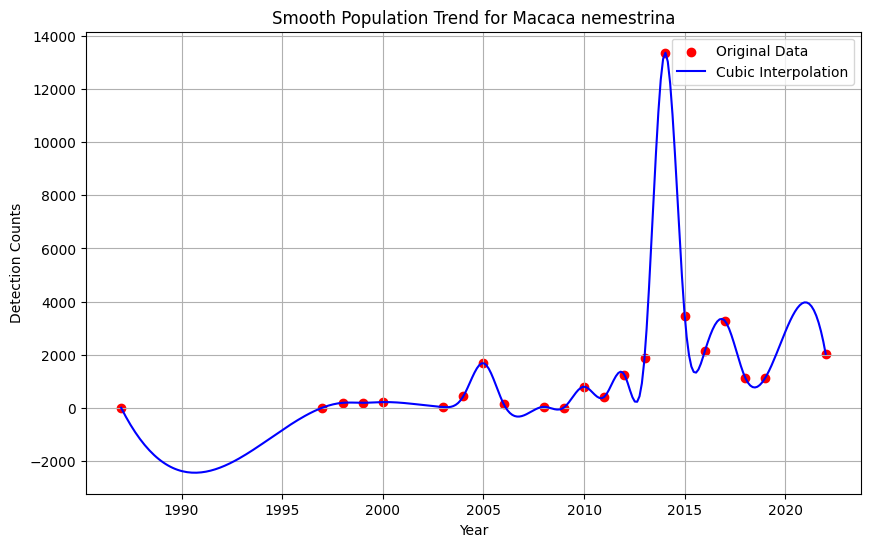

In [ ]:


from scipy.interpolate import interp1d

#Filtering for Macaca nemestrina
macaque = data[data['binomial_verified'] == 'Macaca nemestrina']

#Grouping the data by year_start and summing the records for getting annual detection count[9]
annual = macaque.groupby('year_start')['records'].sum()

print("Annual Detection Counts")
print(annual, "\n")

#Creating two arrays - x for years and y for counts
x = annual.index.values          # years with data
y = annual.values                # summed counts

print("Years:", x)
print("Counts:", y, "\n")

#Creating cubic interpolation function [6][9]
f_cubic = interp1d(x, y, kind='cubic')

#Generating a dense range of years for smooth curve
x_dense = np.linspace(x.min(), x.max(), 300)   # 300 smooth points
y_dense = f_cubic(x_dense)


plt.figure(figsize=(10, 6))

#Original data points
plt.scatter(x, y, color='red', label='Original Data')

#Smooth cubic curve
plt.plot(x_dense, y_dense, color='blue', label='Cubic Interpolation')

plt.xlabel("Year")
plt.ylabel("Detection Counts")
plt.title("Smooth Population Trend for Macaca nemestrina")
plt.legend()            #looks for the labels given above to put a small box in the plot
plt.grid(True)          #adds the horizontal and vertical lines for more readability
plt.show()

---

# Part 2: Object-Oriented Programming 
## Task 7 — Modeling Taxonomy with Inheritance (OOP) 

The **CamTrapAsia** dataset organizes animals into a biological hierarchy: **Order $\rightarrow$ Family $\rightarrow$ Genus $\rightarrow$ Species**. 

For example, a specific detection record might classify an animal as:
* **Order:** Carnivora
* **Family:** Felidae
* **Genus:** *Panthera*
* **Species:** *Panthera tigris* (Tiger)

In this exercise, we will use **Object-Oriented Programming (OOP)** and **Inheritance** to model this structure. We need to distinguish between a "Group" (which contains other items, like a Family) and a "Species" (which is a specific animal with detection records).

**Task:**
Define three classes using the following specifications:

1.  **`BiologicalNode` (Base Class):**
    * Define an `__init__` method that accepts a `name` (string).
    * This class will serve as the parent for both groups and species.

2.  **`Species` (Subclass):**
    * Inherit from `BiologicalNode`.
    * Define an `__init__` method that accepts `name` and `records` (integer).
    * Store `records` as an instance attribute. This represents the number of times this animal was detected.

3.  **`TaxonomicGroup` (Subclass):**
    * Inherit from `BiologicalNode`.
    * Define an `__init__` method that accepts `name` and `rank` (string, e.g., "Family" or "Genus").
    * Initialize an empty list called `children` to store the sub-groups or species inside this group.
    * Define a method `add_child(node)` that appends a `BiologicalNode` (either a `Species` or another `TaxonomicGroup`) to the `children` list.

**🧑‍💻 SOLUTION CELL**

In [ ]:


#Base class representing the biological node in the taxonomy tree [7][9]
class BiologicalNode:
    def __init__(self, name):
        self.name = name     #storing the name of the node like Panthera,Carnivora


#Subclass representing a specific species with records
class Species(BiologicalNode):
    def __init__(self, name, records):
        super().__init__(name)     #calling the parent constructor
        self.records = records     #represents the number of times a specific animal was detected


#Subclass representing a taxonomic group
class TaxonomicGroup(BiologicalNode):
    def __init__(self, name, rank):
        super().__init__(name)
        self.rank = rank        #stores the rank
        self.children = []      #empty list to store Species or other Groups
        
#defining a method that appends the BiologicalNode
    def add_child(self, node):
        self.children.append(node)

In [ ]:


# Create a Group (Genus)
panthera = TaxonomicGroup("Panthera", "Genus")

# Create Species
tiger = Species("Panthera tigris", 150)
leopard = Species("Panthera pardus", 80)

# Link them
panthera.add_child(tiger)
panthera.add_child(leopard)

print(f"Created {panthera.rank}: {panthera.name}")
print(f"Contains: {[child.name for child in panthera.children]}")

Created Genus: Panthera
Contains: ['Panthera tigris', 'Panthera pardus']


## Task 8 — Polymorphism and Recursion 

Now that we have a structure to hold the data, we need a way to calculate the total number of detections. 

* For a **Species**, the count is simply its own `records` value.
* For a **TaxonomicGroup** (like a Genus), the count is the sum of the counts of everything inside it.

This is a perfect use case for **Polymorphism** and **Recursion**. We want to be able to call `.get_count()` on *any* node, and have it return the correct number, regardless of whether it is a Species or a Group.

**Task:**
Re-write your classes from Task 6 to include the following:

1.  **In `BiologicalNode`:**
    * Add a method `get_count(self)` that does nothing (use `pass`). This acts as a placeholder.

2.  **In `Species`:**
    * Implement `get_count(self)` to return the `records` attribute.

3.  **In `TaxonomicGroup`:**
    * Implement `get_count(self)` to calculate the total recursively.
    * The method should iterate through the `children` list, call `.get_count()` on each child, sum the results, and return the total.



**🧑‍💻 SOLUTION CELL**

In [ ]:


#Base class for all biological nodes [8]
class BiologicalNode:
    def __init__(self, name):
        self.name = name

    def get_count(self):
        pass   #placeholder for subclasses

#leaf node representing the species
class Species(BiologicalNode):
    def __init__(self, name, records):
        super().__init__(name)
        self.records = records

    def get_count(self):
        return self.records                 #species count = its own records


class TaxonomicGroup(BiologicalNode):
    def __init__(self, name, rank):
        super().__init__(name)
        self.rank = rank
        self.children = []                  # list of child nodes (Species/TaxonomicGroup)

    def add_child(self, node):              #adding another child
        self.children.append(node)

    def get_count(self):                    #recursively sum the counts of all child nodes
        total = 0
        for child in self.children:
            total += child.get_count()      #recursive call to each child node
        return total

In [ ]:


# 1. Create the high-level group (Order)
order = TaxonomicGroup("Carnivora", "Order")

# 2. Create families
felidae = TaxonomicGroup("Felidae", "Family")
canidae = TaxonomicGroup("Canidae", "Family")

# 3. Create genera
panthera = TaxonomicGroup("Panthera", "Genus")
canis = TaxonomicGroup("Canis", "Genus")

# 4. Create species with known record counts
tiger = Species("Panthera tigris", 150)
leopard = Species("Panthera pardus", 80)
wolf = Species("Canis lupus", 40)
jackal = Species("Canis aureus", 20)

# 5. Build the hierarchy
# Link Species -> Genus
panthera.add_child(tiger)
panthera.add_child(leopard)

canis.add_child(wolf)
canis.add_child(jackal)

# Link Genus -> Family
felidae.add_child(panthera)
canidae.add_child(canis)

# Link Family -> Order
order.add_child(felidae)
order.add_child(canidae)

# 6. Verify Counts
# Expected Totals:
# Panthera: 150 + 80 = 230
# Canis: 40 + 20 = 60
# Felidae: 230
# Canidae: 60
# Order Carnivora: 230 + 60 = 290

print(f"Total detections for {panthera.name}: {panthera.get_count()} (Expected: 230)")
print(f"Total detections for {canis.name}: {canis.get_count()} (Expected: 60)")
print(f"Total detections for {order.name}: {order.get_count()} (Expected: 290)")

# Simple assertions to programmatically check correctness
assert panthera.get_count() == 230, "Error: Panthera count incorrect"
assert canis.get_count() == 60, "Error: Canis count incorrect"
assert order.get_count() == 290, "Error: Total Order count incorrect"

print("\nAll counts verified successfully!")

Total detections for Panthera: 230 (Expected: 230)
Total detections for Canis: 60 (Expected: 60)
Total detections for Carnivora: 290 (Expected: 290)

All counts verified successfully!


## Task 9 — Recursive Visualization with Inheritance 

Let's create a display method that works for both types of nodes.

Add a method `display` to your classes. This method takes an optional argument `level` (defaulting to 0) which determines the indentation.

**In `Species`:**
   * The method should print a string formatted with indentation.
   * **Indentation:** Use 4 spaces repeated `level` times (e.g., `"    " * level`).
   * **Content:** Print the label `[Species]`, followed by the species `name` and its detection count (`records`).
   * **Output Format:** `<indentation>- [Species] <name>: <records> records`
   * *Example:* If level is 2, name is "Panthera tigris", and records is 150, it prints:
      `        - [Species] Panthera tigris: 150 records`

**In `TaxonomicGroup`:**
   * The method has two jobs: print its own details, then tell its children to print theirs.
   * **Step 1 (Print Self):**
      * **Indentation:** Use 4 spaces repeated `level` times.
      * **Content:** Print the `rank` (e.g., "Family"), the group `name`, and the **Total Count** of detections within this group.
      * *Note:* You must call `self.get_count()` to calculate this total dynamically.
      * **Output Format:** `<indentation>> [<rank>] <name> (Total: <total_count>)`
   * **Step 2 (Recurse):**
      * After printing itself, the method must iterate through its `children` list.
      * For each child, call `child.display(level + 1)`. Note that we increase the level by 1 so the child is indented further to the right.

**Example Usage:**
If you construct a tree for the genus *Panthera* (containing Tigers and Leopards) inside the family *Felidae*, calling `felidae.display()` should output something like:

```text
> [Family] Felidae (Total: 230)
    > [Genus] Panthera (Total: 230)
        - [Species] Panthera tigris: 150 records
        - [Species] Panthera pardus: 80 records

**🧑‍💻 SOLUTION CELL**

In [ ]:


#Base class
class BiologicalNode:
    def __init__(self, name):
        self.name = name

    def get_count(self):
        pass

    def display(self, level=0):
        pass
        
#child node
class Species(BiologicalNode):
    def __init__(self, name, records):
        super().__init__(name)
        self.records = records

    def get_count(self):
        return self.records

    def display(self, level=0):
        indent = "    " * level                                                     #Creating indentation: 4 spaces multiplied by level
        print(f"{indent}- [Species] {self.name}: {self.records} records")           #printing the formatted species information


class TaxonomicGroup(BiologicalNode):
    def __init__(self, name, rank):
        super().__init__(name)
        self.rank = rank
        self.children = []
    #method to build the tree by adding a new node to the child nodes
    def add_child(self, node):
        self.children.append(node)

    def get_count(self):
        #recursively summing the count of all child nodes [10]
        total = 0
        for child in self.children:
            total += child.get_count()
        return total

    def display(self, level=0):
        indent = "    " * level     
        total = self.get_count()
        print(f"{indent}> [{self.rank}] {self.name} (Total: {total})")      

        # Recurse into children iterate through child nodes and displaying themsleves
        for child in self.children:
            child.display(level + 1)        #passing 'level + 1' so the children are further to the right

In [17]:
# TESTING CELL (DO NOT MODIFY)

# Create a higher level hierarchy
order = TaxonomicGroup("Carnivora", "Order")
family_cats = TaxonomicGroup("Felidae", "Family")
family_dogs = TaxonomicGroup("Canidae", "Family")

# Add cats
genus_panthera = TaxonomicGroup("Panthera", "Genus")
genus_panthera.add_child(Species("Panthera tigris", 150))
genus_panthera.add_child(Species("Panthera pardus", 80))
family_cats.add_child(genus_panthera)

# Add dogs
genus_canis = TaxonomicGroup("Canis", "Genus")
genus_canis.add_child(Species("Canis aureus", 40)) # Golden Jackal
family_dogs.add_child(genus_canis)

# Link families to Order
order.add_child(family_cats)
order.add_child(family_dogs)

# Display full tree
order.display()

> [Order] Carnivora (Total: 270)
    > [Family] Felidae (Total: 230)
        > [Genus] Panthera (Total: 230)
            - [Species] Panthera tigris: 150 records
            - [Species] Panthera pardus: 80 records
    > [Family] Canidae (Total: 40)
        > [Genus] Canis (Total: 40)
            - [Species] Canis aureus: 40 records


## References

[1] Mendes, C. and Luskin, M. (2024) ‘CamTrapAsia: a dataset of tropical forest vertebrate communities from 239 camera trapping studies’, Ecology. Zenodo. doi:10.5281/zenodo.10780971.

[2] matplotlib.org. (n.d.). matplotlib.pyplot.scatter — Matplotlib 3.5.1 documentation. [online] Available at: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html.

[3] matplotlib.org. (n.d.). Scatter plot — Matplotlib 3.6.2 documentation. [online] Available at: https://matplotlib.org/stable/gallery/shapes_and_collections/scatter.html.

[4] scikit-learn (2019). sklearn.cluster.KMeans — scikit-learn 0.21.3 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html.

[5] docs.scipy.org. (n.d.). scipy.stats.kruskal — SciPy v1.7.1 Manual. [online] Available at: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html.

[6] Scipy.org. (2024). 1-D interpolation — SciPy v1.13.1 Manual. [online] Available at: https://docs.scipy.org/doc/scipy-1.13.1/tutorial/interpolate/1D.html.

[7] W3Schools (2019). Python Inheritance. [online] W3schools.com. Available at: https://www.w3schools.com/python/python_inheritance.asp.

‌[8] W3schools (2019). Java Polymorphism. [online] W3schools.com. Available at: https://www.w3schools.com/java/java_polymorphism.asp.

[9] Blackboard (2024). Blackboard Learn. [online] Lincoln.ac.uk. Available at: https://blackboard.lincoln.ac.uk/ultra/courses/_205604_1/outline 

[10] Jozef (2017). Tree traversal recursion. [online] Stack Overflow. Available at: https://stackoverflow.com/questions/42677906/tree-traversal-recursion.

‌

‌

‌
